# Packages

In [1]:
!pip install tensorflow scikit-learn matplotlib seaborn

In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np

# Helper Functions

In [3]:
# Normalize and one-hot encode datasets
def preprocess_cifar10():
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
    X_train, X_test = X_train / 255.0, X_test / 255.0
    y_train, y_test = to_categorical(y_train, 10), to_categorical(y_test, 10)
    return X_train, X_test, y_train, y_test

def preprocess_mnist():
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
    X_train, X_test = X_train / 255.0, X_test / 255.0
    X_train = X_train[..., tf.newaxis]  # Add channel dimension
    X_test = X_test[..., tf.newaxis]
    y_train, y_test = to_categorical(y_train, 10), to_categorical(y_test, 10)
    return X_train, X_test, y_train, y_test

# Plot training & validation accuracy/loss curves
def plot_training_history(history, model_name):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{model_name} Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} Loss')
    plt.legend()

    plt.show()

# Confusion matrix heatmap
def plot_confusion_matrix(model, X_test, y_test, model_name):
    y_pred = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(y_test, axis=1)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# ROC-AUC curves for multi-class
def plot_roc_auc(model, X_test, y_test, model_name, num_classes=10):
    y_score = model.predict(X_test)
    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test[:,i], y_score[:,i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {i} (AUC={roc_auc:.2f})')
    plt.plot([0,1], [0,1], 'k--')
    plt.title(f'{model_name} ROC Curve')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

# Models

## CNN Baseline

In [4]:
def create_cnn_model(input_shape, num_classes):
    model = models.Sequential()

    # First convolutional block
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2,2)))

    # Second convolutional block
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))

    # Third convolutional block
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))

    # Flatten and fully connected layers
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    # Compile
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

## VGG-16

In [5]:
def create_vgg16_model(input_shape, num_classes):
    base_model = applications.VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze convolutional base

    model = models.Sequential([
        base_model,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

## AlexNet

In [6]:
def create_alexnet(input_shape, num_classes):
    model = models.Sequential()
    model.add(layers.Conv2D(96, (11,11), strides=4, activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D((3,3), strides=2))
    model.add(layers.Conv2D(256, (5,5), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D((3,3), strides=2))
    model.add(layers.Conv2D(384, (3,3), padding='same', activation='relu'))
    model.add(layers.Conv2D(384, (3,3), padding='same', activation='relu'))
    model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D((3,3), strides=2))
    model.add(layers.Flatten())
    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

## GoogleNet

In [7]:
def create_inception_model(input_shape, num_classes):
    base_model = applications.InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze layers

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

## RNN

In [9]:
def create_rnn_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(128, input_shape=input_shape),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Training

## Datasets

In [45]:
(cifar_X_train, cifar_y_train), (cifar_X_test, cifar_y_test) = cifar10.load_data()

# Normalize pixel values to [0,1]
cifar_X_train = cifar_X_train.astype('float32') / 255.0
cifar_X_test  = cifar_X_test.astype('float32') / 255.0

# One-hot encode labels
cifar_y_train = to_categorical(cifar_y_train, 10)
cifar_y_test  = to_categorical(cifar_y_test, 10)

In [46]:
# Load dataset
(mnist_X, mnist_y), (mnist_X, mnist_y) = mnist.load_data()

mnist_X = mnist_X.astype('float32') / 255.0
mnist_X_test = mnist_X_test.astype('float32') / 255.0

# One-hot encode labels
mnist_y_cat = to_categorical(mnist_y, num_classes=10)
mnist_y_test_cat = to_categorical(mnist_y_test, num_classes=10)

## Train Splits

In [47]:
splits = [0.6, 0.7, 0.8, 0.9]

## Train Baseline

In [48]:
cnn_cifar = create_cnn_model((32,32,3), 10)
history_cnn_cifar = cnn_cifar.fit(
    cifar_X_train, cifar_y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)


cnn_mnist = create_cnn_model(input_shape=(28,28,1), num_classes=10)

history_cnn_mnist = cnn_mnist.fit(
    mnist_X,
    mnist_y_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.2740 - loss: 1.9393 - val_accuracy: 0.5109 - val_loss: 1.3361
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5005 - loss: 1.3863 - val_accuracy: 0.6055 - val_loss: 1.1304
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5850 - loss: 1.1912 - val_accuracy: 0.6599 - val_loss: 0.9735
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6303 - loss: 1.0421 - val_accuracy: 0.6812 - val_loss: 0.9230
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6713 - loss: 0.9391 - val_accuracy: 0.7113 - val_loss: 0.8248
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6917 - loss: 0.8805 - val_accuracy: 0.7142 - val_loss: 0.8137
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7177 - loss: 0.8144 - val_accuracy: 0.7269 - val_loss: 0.7870
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7381 - loss: 0.7434 - val_accuracy: 0.

## Train VGG-16

In [ ]:
vgg_cifar = create_vgg16_model(input_shape=(32,32,3), num_classes=10)
history_vgg_cifar = vgg_cifar.fit(
    cifar_X_train,
    cifar_y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

# -----------------------------
# MNIST preprocessing for VGG16
# -----------------------------

# Train VGG16 on MNIST
vgg_mnist = create_vgg16_model(input_shape=(224,224,3), num_classes=10)
history_vgg_mnist = vgg_mnist.fit(
    mnist_X,
    mnist_y_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.3821 - loss: 1.7473 - val_accuracy: 0.5507 - val_loss: 1.2957
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5336 - loss: 1.3282 - val_accuracy: 0.5697 - val_loss: 1.2251
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5564 - loss: 1.2691 - val_accuracy: 0.5870 - val_loss: 1.1871
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5718 - loss: 1.2192 - val_accuracy: 0.5882 - val_loss: 1.1739
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5787 - loss: 1.1988 - val_accuracy: 0.5972 - val_loss: 1.1491
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.5937 - loss: 1.1673 - val_accuracy: 0.6042 - val_loss: 1.1347
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.6035 - loss: 1.1375 - val_accuracy: 0.6043 - val_loss: 1.1385
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.6040 - loss: 1.1225 - val

ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(64, 28, 28), dtype=float32). Expected shape (None, 224, 224, 3), but input has incompatible shape (64, 28, 28)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(64, 28, 28), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

## Train AlexNet

In [ ]:
# Train AlexNet on CIFAR-10
alexnet_cifar = create_alexnet(input_shape=(32,32,3), num_classes=10)
history_alex_cifar = alexnet_cifar.fit(
    cifar_X_train,
    cifar_y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

# Train AlexNet on MNIST
alexnet_mnist = create_alexnet(input_shape=(224,224,3), num_classes=10)
history_alex_mnist = alexnet_mnist.fit(
    mnist_X,
    mnist_y_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)


## Train GoogleNet

In [ ]:
# Train Inception on CIFAR-10
incep_cifar = create_inception_model(input_shape=(32,32,3), num_classes=10)
history_incep_cifar = incep_cifar.fit(
    cifar_X_train,
    cifar_y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

# Train Inception on MNIST
incep_mnist = create_inception_model(input_shape=(299,299,3), num_classes=10)
history_incep_mnist = incep_mnist.fit(
    mnist_X,
    mnist_y_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)


## Train RNN

In [ ]:
# Create RNN model
rnn_mnist = create_rnn_model(input_shape=(28,28), num_classes=10)

# Train RNN
history_rnn_mnist = rnn_mnist.fit(
    mnist_X,
    mnist_y_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)


# Eavluate

## CIFAR-10

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7588 - loss: 0.9019
CNN - CIFAR-10 Test Accuracy: 0.7531


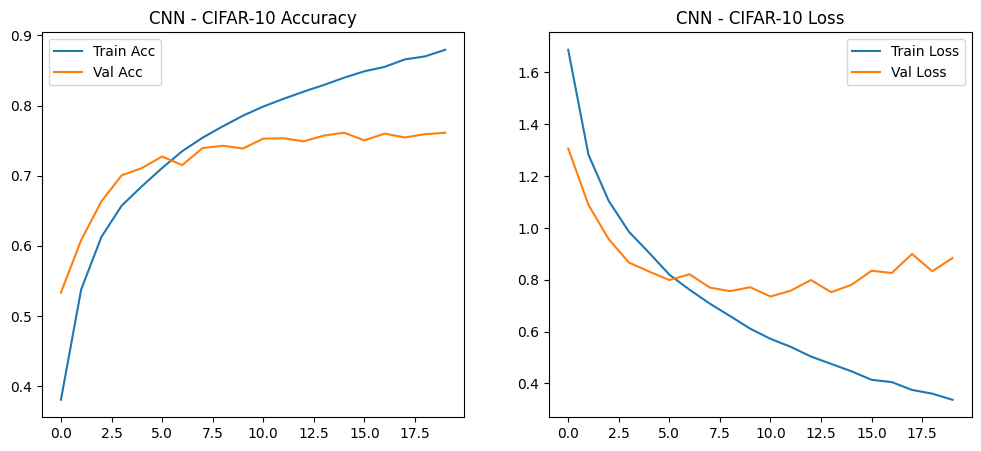

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


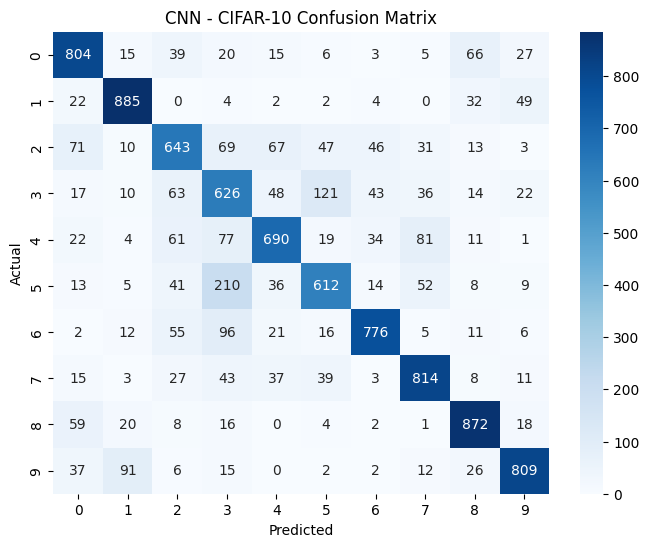

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


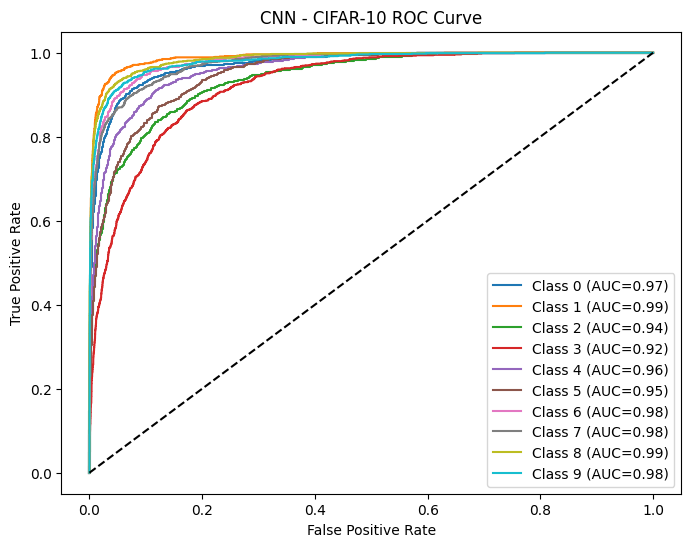

NameError: name 'vgg_cifar' is not defined

In [16]:
# --- CNN ---
cnn_acc = cnn_cifar.evaluate(cifar_X_test, cifar_y_test)[1]
print(f"CNN - CIFAR-10 Test Accuracy: {cnn_acc:.4f}")
plot_training_history(history_cnn_cifar, "CNN - CIFAR-10")
plot_confusion_matrix(cnn_cifar, cifar_X_test, cifar_y_test, "CNN - CIFAR-10")
plot_roc_auc(cnn_cifar, cifar_X_test, cifar_y_test, "CNN - CIFAR-10")

# --- VGG-16 ---
vgg_acc = vgg_cifar.evaluate(cifar_X_test, cifar_y_test)[1]
print(f"VGG-16 - CIFAR-10 Test Accuracy: {vgg_acc:.4f}")
plot_training_history(history_vgg_cifar, "VGG-16 - CIFAR-10")
plot_confusion_matrix(vgg_cifar, cifar_X_test, cifar_y_test, "VGG-16 - CIFAR-10")
plot_roc_auc(vgg_cifar, cifar_X_test, cifar_y_test, "VGG-16 - CIFAR-10")

# --- AlexNet ---
alex_acc = alexnet_cifar.evaluate(cifar_X_test, cifar_y_test)[1]
print(f"AlexNet - CIFAR-10 Test Accuracy: {alex_acc:.4f}")
plot_training_history(history_alex_cifar, "AlexNet - CIFAR-10")
plot_confusion_matrix(alexnet_cifar, cifar_X_test, cifar_y_test, "AlexNet - CIFAR-10")
plot_roc_auc(alexnet_cifar, cifar_X_test, cifar_y_test, "AlexNet - CIFAR-10")

# --- Inception (GoogLeNet) ---
incep_acc = incep_cifar.evaluate(cifar_X_test, cifar_y_test)[1]
print(f"Inception - CIFAR-10 Test Accuracy: {incep_acc:.4f}")
plot_training_history(history_incep_cifar, "Inception - CIFAR-10")
plot_confusion_matrix(incep_cifar, cifar_X_test, cifar_y_test, "Inception - CIFAR-10")
plot_roc_auc(incep_cifar, cifar_X_test, cifar_y_test, "Inception - CIFAR-10")

## MNIST

In [ ]:
# --- CNN ---
cnn_mnist_acc = cnn_mnist.evaluate(mnist_X_test, mnist_y_test_cat)[1]
print(f"CNN - MNIST Test Accuracy: {cnn_mnist_acc:.4f}")
plot_training_history(history_cnn_mnist, "CNN - MNIST")
plot_confusion_matrix(cnn_mnist, mnist_X_test, mnist_y_test_cat, "CNN - MNIST")
plot_roc_auc(cnn_mnist, mnist_X_test, mnist_y_test_cat, "CNN - MNIST")

# --- VGG-16 ---
vgg_mnist_acc = vgg_mnist.evaluate(mnist_X_test, mnist_y_test_cat)[1]
print(f"VGG-16 - MNIST Test Accuracy: {vgg_mnist_acc:.4f}")
plot_training_history(history_vgg_mnist, "VGG-16 - MNIST")
plot_confusion_matrix(vgg_mnist, mnist_X_test, mnist_y_test_cat, "VGG-16 - MNIST")
plot_roc_auc(vgg_mnist, mnist_X_test, mnist_y_test_cat, "VGG-16 - MNIST")

# --- AlexNet ---
alex_mnist_acc = alexnet_mnist.evaluate(mnist_X_test, mnist_y_test_cat)[1]
print(f"AlexNet - MNIST Test Accuracy: {alex_mnist_acc:.4f}")
plot_training_history(history_alex_mnist, "AlexNet - MNIST")
plot_confusion_matrix(alexnet_mnist, mnist_X_test, mnist_y_test_cat, "AlexNet - MNIST")
plot_roc_auc(alexnet_mnist, mnist_X_test, mnist_y_test_cat, "AlexNet - MNIST")

# --- Inception ---
incep_mnist_acc = incep_mnist.evaluate(mnist_X_test, mnist_y_test_cat)[1]
print(f"Inception - MNIST Test Accuracy: {incep_mnist_acc:.4f}")
plot_training_history(history_incep_mnist, "Inception - MNIST")
plot_confusion_matrix(incep_mnist, mnist_X_test, mnist_y_test_cat, "Inception - MNIST")
plot_roc_auc(incep_mnist, mnist_X_test, mnist_y_test_cat, "Inception - MNIST")

# --- RNN (LSTM) ---
rnn_mnist_acc = rnn_mnist.evaluate(mnist_X_test, mnist_y_test_cat)[1]
print(f"RNN (LSTM) - MNIST Test Accuracy: {rnn_mnist_acc:.4f}")
plot_training_history(history_rnn_mnist, "RNN (LSTM) - MNIST")
plot_confusion_matrix(rnn_mnist, mnist_X_test, mnist_y_test_cat, "RNN (LSTM) - MNIST")
plot_roc_auc(rnn_mnist, mnist_X_test, mnist_y_test_cat, "RNN (LSTM) - MNIST")